# Import Required Libraries

In [ ]:

# Install libraries
!pip install pytorch-tabnet lightgbm shap scikit-learn torch torchvision torchaudio --quiet

# Import main libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import lightgbm as lgb
import torch
import warnings

# Import models and preprocessing tools
from pytorch_tabnet.tab_model import TabNetRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error
from lightgbm import early_stopping, log_evaluation

# Setup
warnings.filterwarnings('ignore')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 23.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 85.4 MB/s eta 0:00:00


# Exploratory Data Analysis (EDA)

Amount              0
Severity            0
Age                 0
Private Attorney    0
Marital Status      0
Specialty           0
Insurance           0
Gender              0
dtype: int64


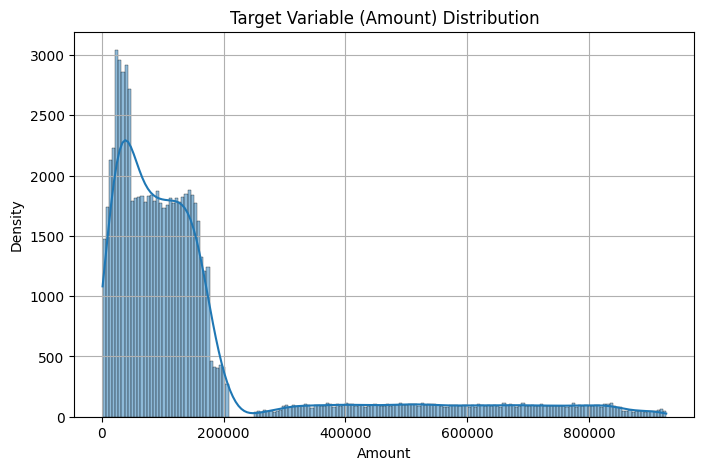

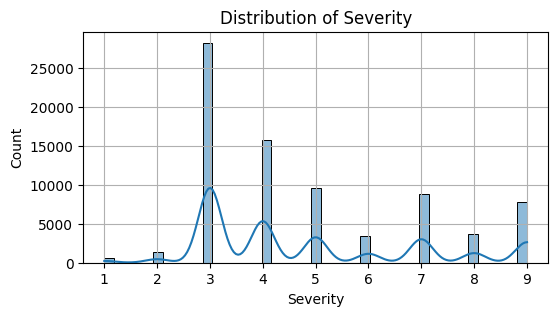

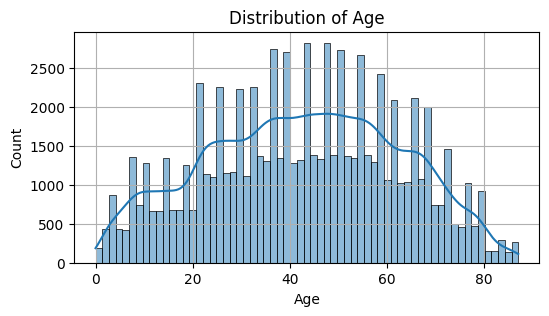

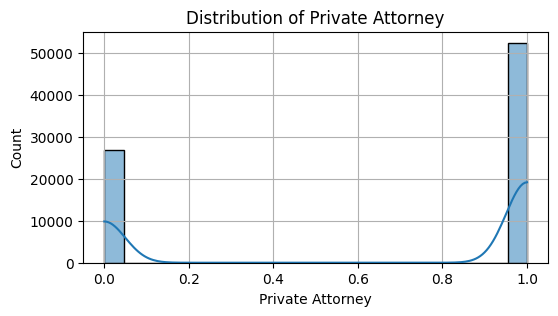

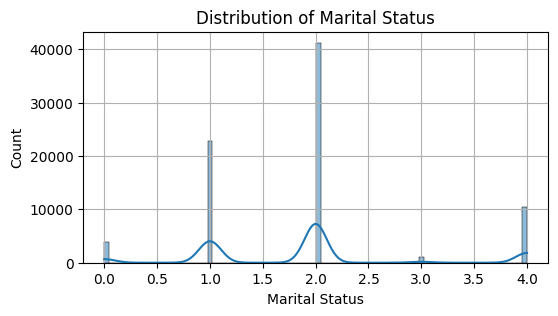

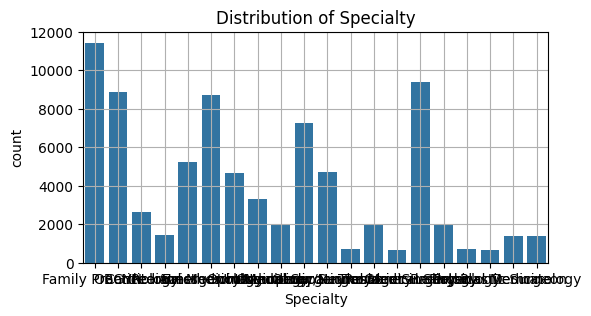

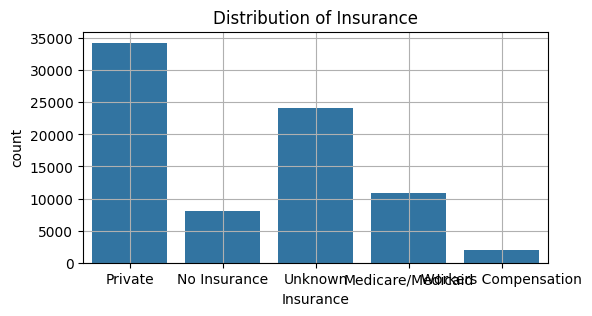

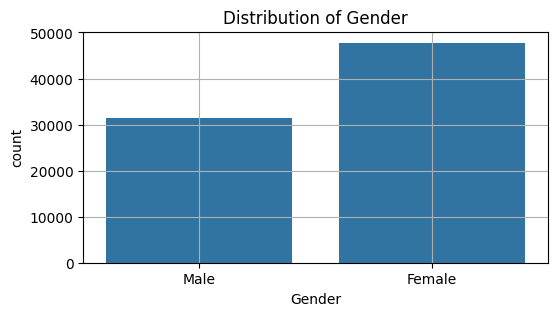

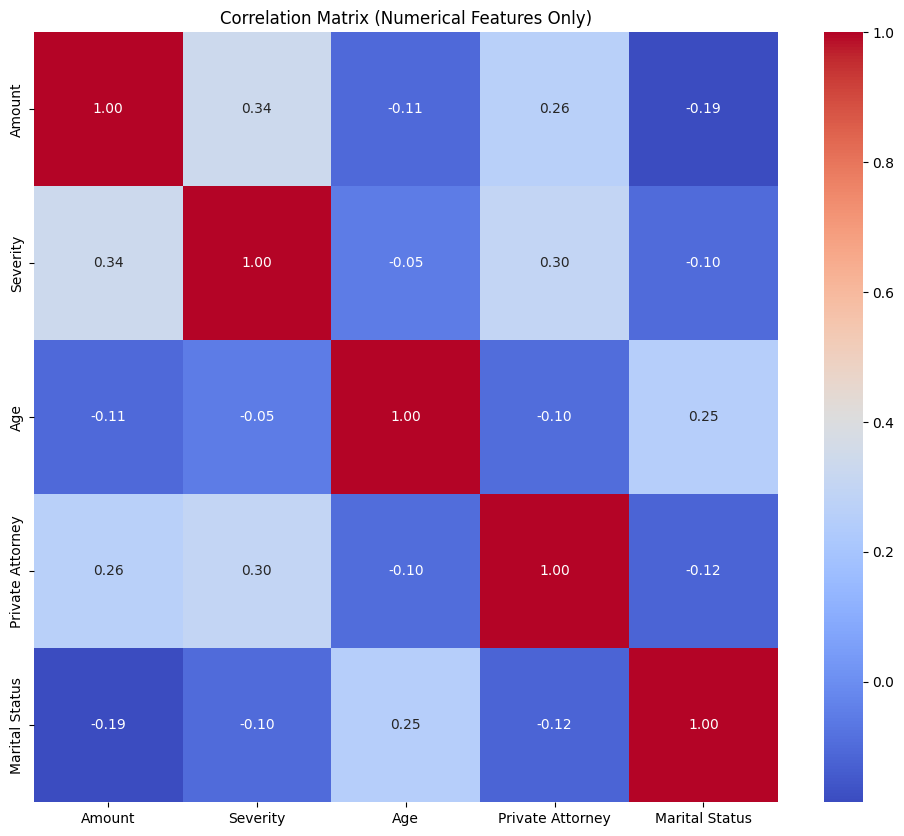

Amount              1.000000
Severity            0.337163
Private Attorney    0.261905
Age                -0.105293
Marital Status     -0.185488
Name: Amount, dtype: float64


In [ ]:

# Load the dataset
df = pd.read_csv('medicalmalpractice.csv')

# Check for missing values
print(df.isnull().sum())

# Plot target variable (Amount)
plt.figure(figsize=(8,5))
sns.histplot(df['Amount'], kde=True)
plt.title('Target Variable (Amount) Distribution')
plt.xlabel('Amount')
plt.ylabel('Density')
plt.grid(True)
plt.show()

# Plot feature distributions
for col in df.drop(columns=['Amount']).columns:
    plt.figure(figsize=(6,3))
    if df[col].dtype in ['int64', 'float64']:
        sns.histplot(df[col], kde=True)
    else:
        sns.countplot(x=col, data=df)
    plt.title(f'Distribution of {col}')
    plt.grid(True)
    plt.show()

# Plot correlation matrix
plt.figure(figsize=(12,10))
sns.heatmap(df.select_dtypes(include=['float64', 'int64']).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix (Numerical Features Only)')
plt.show()

# Show feature correlation with target
cor_target = df.select_dtypes(include=['float64', 'int64']).corr()['Amount'].sort_values(ascending=False)
print(cor_target)

# Create new features
df['Age_Severity'] = df['Age'] * df['Severity']
df['Severity_squared'] = df['Severity'] ** 2
df['Attorney_by_Age'] = df['Private Attorney'] / (df['Age'] + 1)


 # Data Preprocessing and Feature Engineering

In [ ]:
# Prepare Data for Modeling

# Set target and feature columns
target_column = 'Amount'
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
numerical_cols = df.drop(columns=[target_column]).select_dtypes(include=['int64', 'float64']).columns.tolist()

# Split data into features (X) and target (y)
X = df[categorical_cols + numerical_cols]
y = df[target_column]

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create pipeline for numeric features
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

# Create pipeline for categorical features
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine preprocessing for numeric and categorical features
preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numerical_cols),
    ('cat', categorical_transformer, categorical_cols)
])

# Apply preprocessing
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Show processed data shape
print(X_train_processed.shape)


(63368, 34)


# Baseline Model Development

In [ ]:
# Train Random Forest model
print("\n Training Random Forest")
rf_model = RandomForestRegressor(
    n_estimators=300, max_depth=20, min_samples_leaf=2, random_state=42, verbose=1
)
rf_model.fit(X_train_processed, y_train)
y_pred_rf = rf_model.predict(X_test_processed)

# Train LightGBM model
print("\n Training LightGBM")
lgb_train = lgb.Dataset(X_train_processed, label=y_train)
lgb_eval = lgb.Dataset(X_test_processed, label=y_test, reference=lgb_train)

params = {
    'boosting_type': 'gbdt',
    'objective': 'regression',
    'metric': 'rmse',
    'learning_rate': 0.01,
    'num_leaves': 31,
    'feature_fraction': 0.9,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbose': -1
}

lgb_model = lgb.train(
    params,
    lgb_train,
    valid_sets=[lgb_eval],
    num_boost_round=2000,
    callbacks=[early_stopping(stopping_rounds=50), log_evaluation(10)]
)
y_pred_lgb = lgb_model.predict(X_test_processed, num_iteration=lgb_model.best_iteration)

# Train Neural Network (MLP)
print("\n Training Neural Network (MLP)")
mlp = MLPRegressor(
    hidden_layer_sizes=(64, 64),
    activation='relu',
    learning_rate_init=0.001,
    max_iter=500,
    verbose=True,
    random_state=42
)
mlp.fit(X_train_processed, y_train)
y_pred_mlp = mlp.predict(X_test_processed)

# Train TabNet model
print("\n Training TabNet")
tabnet = TabNetRegressor(
    n_d=64, n_a=64, n_steps=5, gamma=1.5,
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=2e-3),
    mask_type='entmax',
    scheduler_params={"step_size":20, "gamma":0.9},
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    verbose=10,
    device_name='cuda' if torch.cuda.is_available() else 'cpu'
)
tabnet.fit(
    X_train=X_train_processed,
    y_train=y_train.values.reshape(-1,1),
    eval_set=[(X_test_processed, y_test.values.reshape(-1,1))],
    eval_name=['valid'],
    eval_metric=['rmse'],
    max_epochs=200,
    patience=20,
    batch_size=512,
    virtual_batch_size=128,
    num_workers=0,
    drop_last=False
)
y_pred_tabnet = tabnet.predict(X_test_processed).reshape(-1)



 Training Random Forest


[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:   17.4s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:   53.3s
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.2s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    0.7s



 Training LightGBM
Training until validation scores don't improve for 50 rounds
[10]	valid_0's rmse: 185944
[20]	valid_0's rmse: 177773
[30]	valid_0's rmse: 170697
[40]	valid_0's rmse: 164588
[50]	valid_0's rmse: 159273
[60]	valid_0's rmse: 154789
[70]	valid_0's rmse: 150779
[80]	valid_0's rmse: 147437
[90]	valid_0's rmse: 144251
[100]	valid_0's rmse: 141548
[110]	valid_0's rmse: 139191
[120]	valid_0's rmse: 137190
[130]	valid_0's rmse: 135280
[140]	valid_0's rmse: 133643
[150]	valid_0's rmse: 132219
[160]	valid_0's rmse: 130928
[170]	valid_0's rmse: 129806
[180]	valid_0's rmse: 128780
[190]	valid_0's rmse: 127884
[200]	valid_0's rmse: 126957
[210]	valid_0's rmse: 126264
[220]	valid_0's rmse: 125540
[230]	valid_0's rmse: 124916
[240]	valid_0's rmse: 124407
[250]	valid_0's rmse: 123944
[260]	valid_0's rmse: 123486
[270]	valid_0's rmse: 122945
[280]	valid_0's rmse: 122469
[290]	valid_0's rmse: 122087
[300]	valid_0's rmse: 121617
[310]	valid_0's rmse: 121293
[320]	valid_0's rmse: 120975


# Baseline Model Evaluation: RMSE Analysis

In [ ]:
# Prepare predictions from all models
models = {
    'Random Forest': y_pred_rf,
    'LightGBM': y_pred_lgb,
    'Neural Network (MLP)': y_pred_mlp,
    'TabNet': y_pred_tabnet
}

# Evaluate each model
results = []
for name, preds in models.items():
    mse = mean_squared_error(y_test, preds)
    rmse = np.sqrt(mse)
    results.append((name, rmse))
    print(f"{name} RMSE: {rmse:,.0f}")

# Create a leaderboard of models based on RMSE
results_df = pd.DataFrame(results, columns=["Model", "RMSE"]).sort_values("RMSE")
print("\n🏆 Model Leaderboard:")
print(results_df)

# Prepare SHAP explainer for LightGBM model
explainer = shap.TreeExplainer(lgb_model)


Random Forest RMSE: 119,855
LightGBM RMSE: 116,316
Neural Network (MLP) RMSE: 125,741
TabNet RMSE: 114,792

🏆 Model Leaderboard:
                  Model           RMSE
3                TabNet  114792.220503
1              LightGBM  116315.821665
0         Random Forest  119855.069959
2  Neural Network (MLP)  125740.975125


# Calculate and visualize feature importance using SHAP values


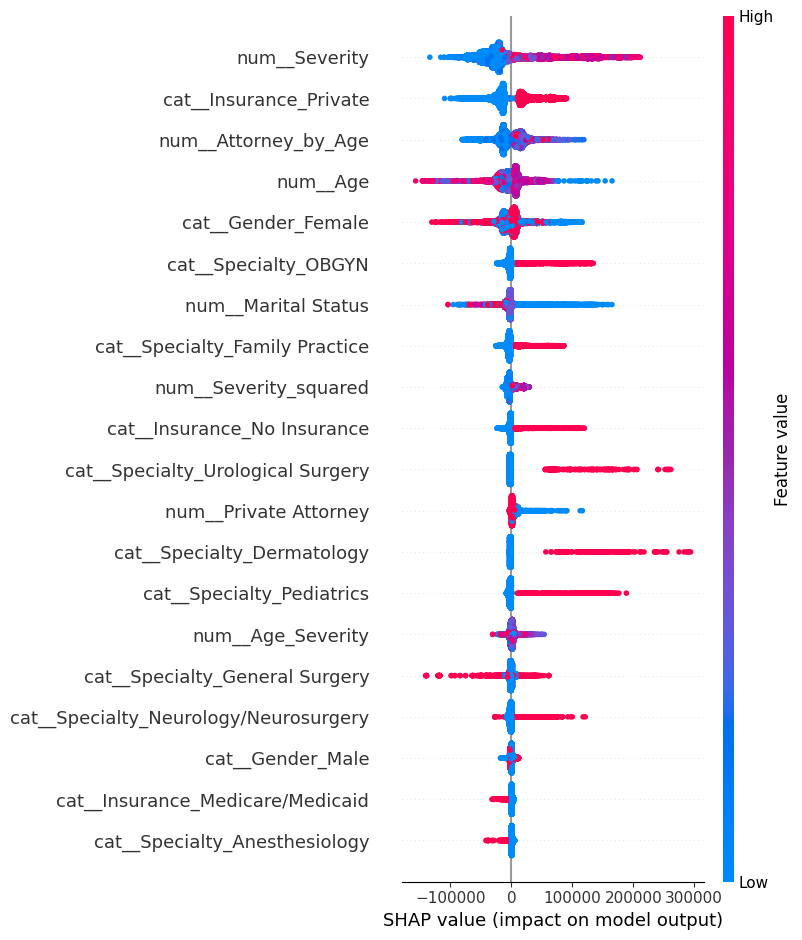

In [ ]:
# Import libraries
import shap
import matplotlib.pyplot as plt

# Create SHAP explainer for LightGBM model
explainer = shap.TreeExplainer(lgb_model)

# Calculate SHAP values for the test set
shap_values = explainer.shap_values(X_test_processed)

# Plot SHAP summary plot
plt.figure()
shap.summary_plot(shap_values, X_test_processed, feature_names=preprocessor.get_feature_names_out())
plt.show()


# Baseline Model Evaluation: R² Score Analysis

In [ ]:
# Import libraries for evaluation
from sklearn.metrics import r2_score
from sklearn.model_selection import RandomizedSearchCV, cross_val_score

# Print R² scores for all models
print("\n📈 R² Scores for Initial Models")
print(f"Random Forest R²: {r2_score(y_test, y_pred_rf):.4f}")
print(f"LightGBM R²: {r2_score(y_test, y_pred_lgb):.4f}")
print(f"Neural Network (MLP) R²: {r2_score(y_test, y_pred_mlp):.4f}")
print(f"TabNet R²: {r2_score(y_test, y_pred_tabnet):.4f}")



📈 R² Scores for Initial Models
Random Forest R²: 0.6238
LightGBM R²: 0.6457
Neural Network (MLP) R²: 0.5859
TabNet R²: 0.6549


# Hyperparameter Optimization: Random Forest

In [ ]:

# Set hyperparameter grid for Random Forest
rf_param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['auto', 'sqrt']
}

# Setup RandomizedSearchCV for Random Forest
rf_random_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=rf_param_grid,
    n_iter=20,
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# Train Random Forest with hyperparameter tuning
print("\n Hyperparameter Tuning Random Forest...")
rf_random_search.fit(X_train_processed, y_train)
best_rf = rf_random_search.best_estimator_

# Predict and evaluate tuned Random Forest
y_pred_best_rf = best_rf.predict(X_test_processed)
print(f"Best Random Forest RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_best_rf)):.0f}")
print(f"Best Random Forest R²: {r2_score(y_test, y_pred_best_rf):.4f}")

# Cross-validation score on tuned Random Forest
rf_cv_scores = cross_val_score(best_rf, X_train_processed, y_train, cv=5, scoring='r2')
print(f"Cross-Validated R² (Random Forest): {np.mean(rf_cv_scores):.4f}")



 Hyperparameter Tuning Random Forest...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best Random Forest RMSE: 116320
Best Random Forest R²: 0.6456
Cross-Validated R² (Random Forest): 0.6552


# Hyperparameter Optimization: Neural Network (MLP)

In [ ]:
# Import libraries
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import RandomizedSearchCV

# Set hyperparameter grid for MLP
mlp_param_grid = {
    'hidden_layer_sizes': [(64, 64), (128, 64), (128, 128)],
    'activation': ['relu', 'tanh'],
    'learning_rate_init': [0.001, 0.005],
    'alpha': [0.0001, 0.001]
}

# Setup RandomizedSearchCV for MLP
mlp_random_search = RandomizedSearchCV(
    estimator=MLPRegressor(max_iter=300, early_stopping=True, random_state=42),
    param_distributions=mlp_param_grid,
    n_iter=10,
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# Train MLP with hyperparameter tuning
print("\n Safer Hyperparameter Tuning for Neural Network (MLP)...")
mlp_random_search.fit(X_train_processed, y_train)
best_mlp = mlp_random_search.best_estimator_

# Predict and evaluate tuned MLP
y_pred_best_mlp = best_mlp.predict(X_test_processed)
print(f"Best MLP RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_best_mlp)):.0f}")
print(f"Best MLP R²: {r2_score(y_test, y_pred_best_mlp):.4f}")



 Safer Hyperparameter Tuning for Neural Network (MLP)...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best MLP RMSE: 122271
Best MLP R²: 0.6085


# Hyperparameter Optimization: LightGBM

In [ ]:
# Import libraries
import lightgbm as lgb
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score

# Set hyperparameter grid for LightGBM
lgbm_param_grid = {
    'num_leaves': [20, 31, 40, 50],
    'max_depth': [-1, 5, 10, 15],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 300, 500],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'reg_alpha': [0, 0.1, 0.5],
    'reg_lambda': [0, 0.1, 0.5]
}

# Setup RandomizedSearchCV for LightGBM
lgbm_random_search = RandomizedSearchCV(
    estimator=lgb.LGBMRegressor(objective='regression', random_state=42),
    param_distributions=lgbm_param_grid,
    n_iter=20,
    scoring='r2',
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# Train LightGBM with hyperparameter tuning
print("\n🟠 Hyperparameter Tuning for LightGBM...")
lgbm_random_search.fit(X_train_processed, y_train)

# Get best LightGBM model
best_lgbm = lgbm_random_search.best_estimator_

# Predict and evaluate tuned LightGBM
y_pred_best_lgbm = best_lgbm.predict(X_test_processed)

print(f"Best LightGBM RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_best_lgbm)):.0f}")
print(f"Best LightGBM R²: {r2_score(y_test, y_pred_best_lgbm):.4f}")

# Show best parameters
print("\n🏆 Best Parameters for LightGBM:")
print(lgbm_random_search.best_params_)



🟠 Hyperparameter Tuning for LightGBM...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best LightGBM RMSE: 115925
Best LightGBM R²: 0.6480

🏆 Best Parameters for LightGBM:
{'subsample': 1.0, 'reg_lambda': 0.5, 'reg_alpha': 0.1, 'num_leaves': 50, 'n_estimators': 300, 'max_depth': -1, 'learning_rate': 0.05, 'colsample_bytree': 0.8}


# Hyperparameter Optimization: TabNet

In [ ]:
# Import libraries
from pytorch_tabnet.tab_model import TabNetRegressor
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.base import BaseEstimator, RegressorMixin
import torch

# Define TabNet model wrapper for scikit-learn
class TabNetWrapper(BaseEstimator, RegressorMixin):
    def __init__(self, n_d=8, n_a=8, n_steps=3, gamma=1.0):
        self.n_d = n_d
        self.n_a = n_a
        self.n_steps = n_steps
        self.gamma = gamma
        self.model = None

    def fit(self, X, y):
        X_train_fold, X_val_fold, y_train_fold, y_val_fold = train_test_split(X, y, test_size=0.2, random_state=42)

        self.model = TabNetRegressor(
            n_d=self.n_d, n_a=self.n_a, n_steps=self.n_steps,
            gamma=self.gamma,
            optimizer_fn=torch.optim.Adam,
            mask_type='entmax',
            verbose=0,
            device_name='cuda' if torch.cuda.is_available() else 'cpu'
        )

        self.model.fit(
            X_train=X_train_fold,
            y_train=y_train_fold.reshape(-1, 1),
            eval_set=[(X_val_fold, y_val_fold.reshape(-1, 1))],
            eval_name=["valid"],
            eval_metric=["rmse"],
            max_epochs=50,
            patience=5,
            batch_size=512,
            virtual_batch_size=128,
            num_workers=0,
            drop_last=False
        )
        return self

    def predict(self, X):
        return self.model.predict(X).reshape(-1)

# Set hyperparameter grid for TabNet
tabnet_param_grid = {
    'n_d': [8, 16],
    'n_a': [8, 16],
    'n_steps': [3, 4],
    'gamma': [1.0, 1.5]
}

# Setup RandomizedSearchCV for TabNet
tabnet_random_search = RandomizedSearchCV(
    estimator=TabNetWrapper(),
    param_distributions=tabnet_param_grid,
    n_iter=4,
    cv=2,
    verbose=2,
    random_state=42,
    n_jobs=1
)

# Train TabNet with hyperparameter tuning
print("\nHyperparameter Tuning for TabNet...")
tabnet_random_search.fit(X_train_processed, y_train.values)

# Get best TabNet model
best_tabnet = tabnet_random_search.best_estimator_

# Predict and evaluate tuned TabNet
y_pred_best_tabnet = best_tabnet.predict(X_test_processed)

print(f"Best TabNet RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_best_tabnet)):.0f}")
print(f"Best TabNet R²: {r2_score(y_test, y_pred_best_tabnet):.4f}")

# Show best parameters
print("\nBest TabNet Parameters:")
print(tabnet_random_search.best_params_)



🟢 Super-Light Fast TabNet Tuning Started...
Fitting 2 folds for each of 4 candidates, totalling 8 fits
Stop training because you reached max_epochs = 50 with best_epoch = 49 and best_valid_rmse = 199215.22319
[CV] END .................gamma=1.0, n_a=8, n_d=8, n_steps=3; total time= 2.0min
Stop training because you reached max_epochs = 50 with best_epoch = 49 and best_valid_rmse = 190990.18714
[CV] END .................gamma=1.0, n_a=8, n_d=8, n_steps=3; total time= 1.9min
Stop training because you reached max_epochs = 50 with best_epoch = 48 and best_valid_rmse = 174184.86253
[CV] END .................gamma=1.0, n_a=8, n_d=8, n_steps=4; total time= 2.3min
Stop training because you reached max_epochs = 50 with best_epoch = 48 and best_valid_rmse = 175243.02084
[CV] END .................gamma=1.0, n_a=8, n_d=8, n_steps=4; total time= 2.3min

Early stopping occurred at epoch 47 with best_epoch = 42 and best_valid_rmse = 190899.45919
[CV] END ................gamma=1.0, n_a=16, n_d=8, n_st